In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests # <--- New import for our disguise
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import yfinance as yf

# 1. Create a custom session to trick Yahoo Finance into thinking we are a real web browser
session = requests.Session()
session.headers['User-agent'] = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'

print("Fetching TSLA data using browser spoofing...")
data = yf.download('TSLA', start='2015-01-01', end='2026-06-30', session=session)

# Strip confusing timezones from the index
data.index = pd.to_datetime(data.index).tz_localize(None)

# 2. Extract Close prices cleanly as a 1D Series
if isinstance(data.columns, pd.MultiIndex):
    tsla_series = data['Close']['TSLA'].copy()
else:
    tsla_series = data['Close'].copy()

tsla_series = tsla_series.squeeze() # Force into 1D Series

# 3. Chronological Split (Train: 2015-2024, Test: 2025-June 2026)
train_data = tsla_series[:'2024-12-31']
test_data = tsla_series['2025-01-01':'2026-06-30']

print(f"\n--- SUCCESS! ---")
print(f"Training observations (2015-2024): {len(train_data)}")
print(f"Testing observations (2025-2026): {len(test_data)}")

Fetching TSLA data using browser spoofing...


[*********************100%***********************]  1 of 1 completed


--- SUCCESS! ---
Training observations (2015-2024): 2516
Testing observations (2025-2026): 372


Running auto_arima to find the optimal (p, d, q) parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.50 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.290 seconds

--- Optimal ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Mon, 06 Jul 2026   AIC                          16368.109
Time:                        21:17:27   BIC                          16373.939
Sample:                             0   HQIC        

/Users/tekabe/Downloads/week9/portfolio-optimization/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/tekabe/Downloads/week9/portfolio-optimization/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


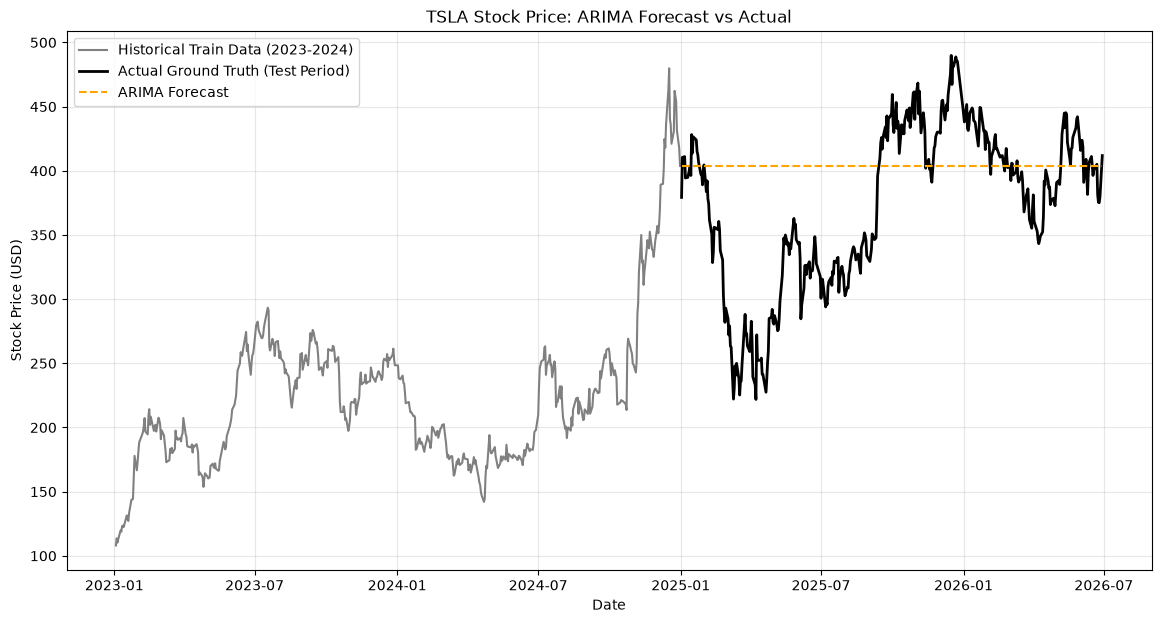

In [10]:
# Cell 2: Implement and Optimize ARIMA Model
from pmdarima import auto_arima
import matplotlib.pyplot as plt

print("Running auto_arima to find the optimal (p, d, q) parameters...")
# auto_arima automatically searches for the best parameters to minimize AIC
arima_model = auto_arima(
    train_data, 
    start_p=0, start_q=0,
    max_p=5, max_q=5, 
    d=None,           # Let the model determine the optimal differencing (d)
    seasonal=False,   # Standard stock prices typically don't have calendar seasonality
    trace=True,       # Shows the search progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True     # Uses a smart search algorithm to find parameters faster
)

print("\n--- Optimal ARIMA Model Found ---")
print(arima_model.summary())

# Generate forecasts for the exact length of the test period
print("\nGenerating forecasts for the test period (2025-2026)...")
n_periods = len(test_data)
arima_forecast_values = arima_model.predict(n_periods=n_periods)

# Convert the forecast into a pandas Series with the correct test dates as the index
arima_forecast = pd.Series(arima_forecast_values.values, index=test_data.index)

# Plot the Train, Actual Test, and Forecasted data
plt.figure(figsize=(14, 7))
# Plotting just the last 2 years of training data for better visual scale
plt.plot(train_data['2023-01-01':], label='Historical Train Data (2023-2024)', color='gray')
plt.plot(test_data, label='Actual Ground Truth (Test Period)', color='black', linewidth=2)
plt.plot(arima_forecast, label='ARIMA Forecast', color='orange', linestyle='--')

plt.title("TSLA Stock Price: ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Cell 3: LSTM Data Preprocessing & Windowing
# LSTMs are sensitive to scale; fit scaler ONLY on training data to prevent data leakage
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data.values.reshape(-1, 1))

# Combine the end of training data with test data to allow lookback for the first test points
total_lookback_data = pd.concat((train_data[-60:], test_data), axis=0).values
scaled_total = scaler.transform(total_lookback_data.reshape(-1, 1))

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Prepare training structures
X_train, y_train = create_sequences(scaled_train, window_size=60)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Prepare testing structures
X_test, y_test = create_sequences(scaled_total, window_size=60)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"LSTM Training Shape: {X_train.shape}")
print(f"LSTM Testing Shape: {X_test.shape}")



LSTM Training Shape: (2456, 60, 1)
LSTM Testing Shape: (372, 60, 1)


In [12]:
# =====================================================================

# Cell 4: Build, Train, and Forecast LSTM
# Define Neural Network Architecture
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

print("Training LSTM Model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Generate Predictions & Inverse Scale to original USD format
lstm_predictions_scaled = model.predict(X_test)
lstm_forecast = scaler.inverse_transform(lstm_predictions_scaled).flatten()
lstm_forecast_series = pd.Series(lstm_forecast, index=test_data.index)

/Users/tekabe/Downloads/week9/portfolio-optimization/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM Model...
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 0.0120 - val_loss: 0.0034
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0018 - val_loss: 0.0031
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0016 - val_loss: 0.0042
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0014 - val_loss: 0.0026
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 8.7729e-04 - val_loss: 0.0015
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━


--- Model Performance Comparison ---


,ARIMA,LSTM
Metric,,
MAE (USD),54.44,17.22
RMSE (USD),70.54,21.40
MAPE (%),17.24,4.62


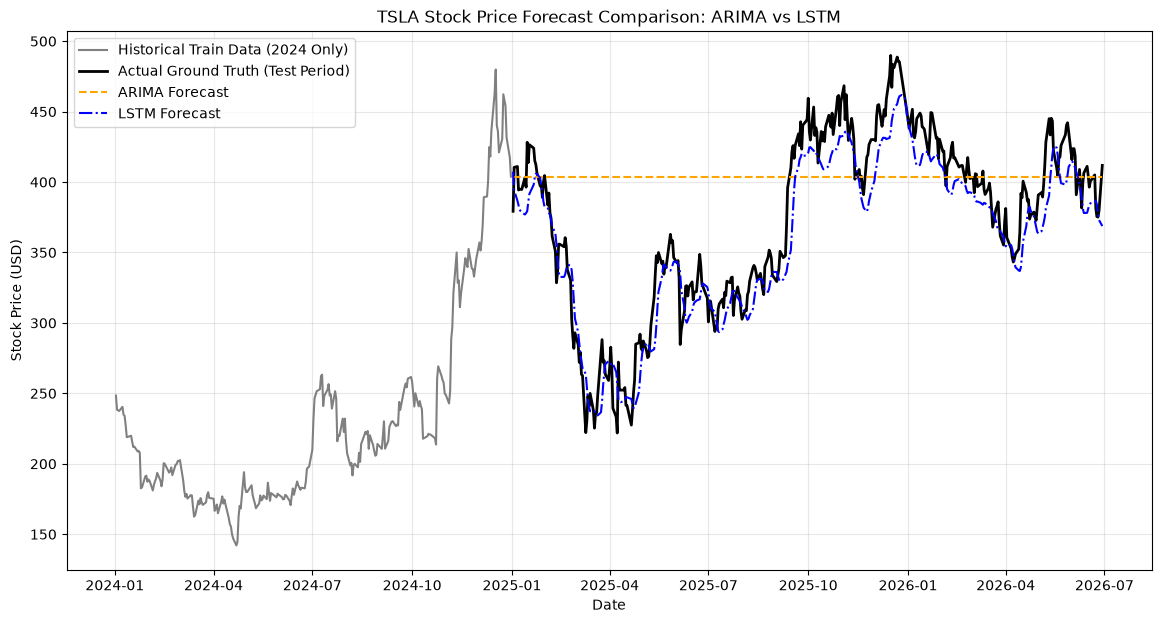

In [13]:
# Cell 5: Calculate Error Metrics & Plot Results
def calculate_mape(actual, predicted):
    # Convert to raw numpy arrays to prevent pandas index alignment from causing NaNs
    actual_arr = np.array(actual)
    predicted_arr = np.array(predicted)
    return np.mean(np.abs((actual_arr - predicted_arr) / actual_arr)) * 100

# Evaluation Metrics for ARIMA (Assuming arima_forecast is still in memory)
arima_mae = mean_absolute_error(test_data, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_data, arima_forecast))
arima_mape = calculate_mape(test_data, arima_forecast)

# Evaluation Metrics for LSTM
lstm_mae = mean_absolute_error(test_data, lstm_forecast_series)
lstm_rmse = np.sqrt(mean_squared_error(test_data, lstm_forecast_series))
lstm_mape = calculate_mape(test_data, lstm_forecast_series)

# Construct Comparison Table
metrics_df = pd.DataFrame({
    'Metric': ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)'],
    'ARIMA': [arima_mae, arima_rmse, arima_mape],
    'LSTM': [lstm_mae, lstm_rmse, lstm_mape]
}).set_index('Metric')

print("\n--- Model Performance Comparison ---")
display(metrics_df.round(2))

# Plot Visual Comparison
plt.figure(figsize=(14, 7))
plt.plot(train_data['2024-01-01':], label='Historical Train Data (2024 Only)', color='gray')
plt.plot(test_data, label='Actual Ground Truth (Test Period)', color='black', linewidth=2)
plt.plot(arima_forecast, label='ARIMA Forecast', color='orange', linestyle='--')
plt.plot(lstm_forecast_series, label='LSTM Forecast', color='blue', linestyle='-.')
plt.title("TSLA Stock Price Forecast Comparison: ARIMA vs LSTM")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import os
import joblib

print("Creating directory and saving artifacts...")

# Create the target directory if it doesn't already exist
save_dir = '../data/processed/'
os.makedirs(save_dir, exist_ok=True)

# 1. Save the trained LSTM model (TF 2.16+ uses .keras format)
model.save(f'{save_dir}tsla_lstm_model.keras')

# 2. Save the MinMaxScaler
joblib.dump(scaler, f'{save_dir}tsla_scaler.pkl')

# 3. Save the test_data
test_data.to_csv(f'{save_dir}tsla_test_data.csv')

print("All artifacts successfully saved to /data/processed/")

Creating directory and saving artifacts...
All artifacts successfully saved to /data/processed/


In [16]:
import os
print(os.path.abspath('../data/processed/'))

/Users/tekabe/Downloads/week9/data/processed


In [17]:
import os
import joblib

print("Creating directory and saving artifacts...")

# CHANGED: Using './' to create the folder in the exact same directory as this notebook
save_dir = './data/processed/'
os.makedirs(save_dir, exist_ok=True)

# 1. Save the trained LSTM model
model.save(f'{save_dir}tsla_lstm_model.keras')

# 2. Save the MinMaxScaler
joblib.dump(scaler, f'{save_dir}tsla_scaler.pkl')

# 3. Save the test_data
test_data.to_csv(f'{save_dir}tsla_test_data.csv')

print(f"All artifacts successfully saved to: {os.path.abspath(save_dir)}")

Creating directory and saving artifacts...
All artifacts successfully saved to: /Users/tekabe/Downloads/week9/portfolio-optimization/data/processed
